## Logistic Regression

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
from sklearn.datasets import make_classification

In [56]:
X,y = make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=42)

In [57]:
X=pd.DataFrame(X)
y=pd.Series(y)

In [58]:
y

0      0
1      1
2      1
3      0
4      1
      ..
995    1
996    1
997    0
998    0
999    0
Length: 1000, dtype: int64

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

#### Model Training

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
logistic=LogisticRegression()

In [62]:
logistic.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
y_pred=logistic.predict(X_test)

In [64]:
# #### Prediction With the Probability (No Need In this case)
# logistic.predict_proba(X_test)

In [65]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)

In [66]:
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")

Accuracy is : 0.8466666666666667
 Confusion Matrix:
 [[118  17]
 [ 29 136]]


In [67]:
print(f'Classification Report: {cr}')

Classification Report:               precision    recall  f1-score   support

           0       0.80      0.87      0.84       135
           1       0.89      0.82      0.86       165

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



## Hyper Parameter Tuning and Cross Validation

In [68]:
model = LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c=[100,10,1,0.1,0.01,0.02]
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
class_weight=['balanced']
params=dict(penalty=penalty,C=c,class_weight=class_weight,solver=solver)

## Grid SearchCV

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [76]:
from sklearn.model_selection import GridSearchCV 
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [77]:
grid

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [78]:
grid.fit(X_train,y_train)

d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
300 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = _check_solver(self.solver, self.p

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [79]:
grid.best_params_

{'C': 0.02, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}

In [80]:
grid.best_score_

np.float64(0.8757142857142857)

In [81]:
y_pred=grid.predict(X_test)

In [82]:
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)

In [83]:
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")

Accuracy is : 0.8566666666666667
 Confusion Matrix:
 [[122  13]
 [ 30 135]]


In [84]:
print(f'Classification Report: {cr}')

Classification Report:               precision    recall  f1-score   support

           0       0.80      0.90      0.85       135
           1       0.91      0.82      0.86       165

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



## Randomized SearchCV

In [85]:
from sklearn.model_selection import RandomizedSearchCV
model = LogisticRegression()
rscv= RandomizedSearchCV(estimator=model,param_distributions=params,cv=5,scoring='accuracy')
rscv.fit(X_train,y_train)

d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py:516:

,estimator,LogisticRegression()
,param_distributions,"{'C': [100, 10, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [86]:
rscv.best_score_

np.float64(0.8685714285714287)

In [87]:
rscv.best_params_

{'solver': 'sag', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 100}

In [88]:
y_pred=rscv.predict(X_test)

In [89]:
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)

In [90]:
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")

Accuracy is : 0.8366666666666667
 Confusion Matrix:
 [[114  21]
 [ 28 137]]


In [91]:
print(f'Classification Report: {cr}')

Classification Report:               precision    recall  f1-score   support

           0       0.80      0.84      0.82       135
           1       0.87      0.83      0.85       165

    accuracy                           0.84       300
   macro avg       0.83      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



## Logistic Regression With Multiple Classes

In [106]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,n_features=10,n_informative=3,n_classes=3,random_state=42)

In [107]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [109]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(multi_class='ovr')

In [112]:
logistic.fit(X_train,y_train)
y_pred=logistic.predict(X_test)

d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [113]:
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)

In [114]:
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")

Accuracy is : 0.68
 Confusion Matrix:
 [[79 16  8]
 [31 38 27]
 [ 3 11 87]]


In [115]:
print(f'Classification Report: {cr}')

Classification Report:               precision    recall  f1-score   support

           0       0.70      0.77      0.73       103
           1       0.58      0.40      0.47        96
           2       0.71      0.86      0.78       101

    accuracy                           0.68       300
   macro avg       0.67      0.67      0.66       300
weighted avg       0.67      0.68      0.66       300



## Randomized Search CV

In [118]:
from sklearn.model_selection import RandomizedSearchCV
model=LogisticRegression()
rscv = RandomizedSearchCV(estimator=model,scoring='accuracy',param_distributions=params,cv=5)
rscv.fit(X_train,y_train)


d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which suppor

,estimator,LogisticRegression()
,param_distributions,"{'C': [100, 10, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [119]:
y_pred=rscv.predict(X_test)

In [ ]:
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")
print(f'Classification Report: {cr}')

In [121]:
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")

Accuracy is : 0.6633333333333333
 Confusion Matrix:
 [[83  7 13]
 [42 20 34]
 [ 2  3 96]]


In [122]:
print(f'Classification Report: {cr}')

Classification Report:               precision    recall  f1-score   support

           0       0.65      0.81      0.72       103
           1       0.67      0.21      0.32        96
           2       0.67      0.95      0.79       101

    accuracy                           0.66       300
   macro avg       0.66      0.65      0.61       300
weighted avg       0.66      0.66      0.61       300



## Logistic Regression with imbalanced dataset

In [123]:
from collections import Counter
from sklearn.datasets import make_classification

In [130]:
X,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)

<Axes: xlabel='0', ylabel='1'>

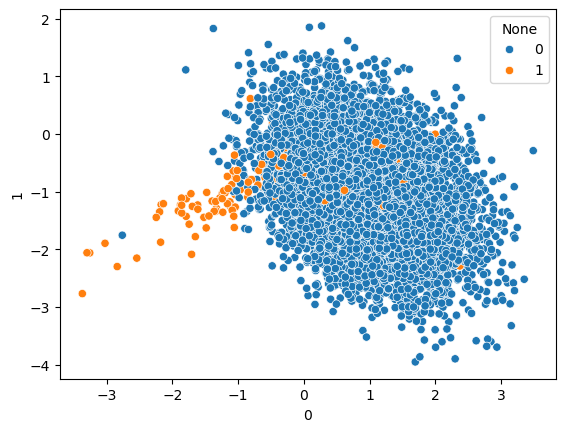

In [138]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

In [139]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [140]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
c=[100,10,1.0,0.1,0.01]
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [142]:
params=dict(penalty=penalty,C=c,solver=solver,class_weight=class_weight)

In [143]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
from sklearn.model_selection import GridSearchCV 
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [145]:
grid.fit(X_train,y_train)

d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
4000 fits failed out of a total of 7200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = _check_solver(self.solver, sel

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [146]:
grid.best_params_

{'C': 0.01, 'class_weight': {0: 10, 1: 50}, 'penalty': 'l2', 'solver': 'lbfgs'}

In [147]:
grid.error_score

nan

In [148]:
grid.best_score_

np.float64(0.9881333333333334)

In [149]:
y_pred=grid.predict(X_test)

In [153]:
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f'Classification Report: {cr}')
print(f"Accuracy is : {acc}\n Confusion Matrix:\n {cm}")

Classification Report:               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2470
           1       0.86      0.40      0.55        30

    accuracy                           0.99      2500
   macro avg       0.92      0.70      0.77      2500
weighted avg       0.99      0.99      0.99      2500

Accuracy is : 0.992
 Confusion Matrix:
 [[2468    2]
 [  18   12]]
